# 10 · Búsqueda de lugares, instituciones y marcadores COM-B

Equivalente al notebook `12_busqueda_lugares_personajes.ipynb` de Karen.
Busca menciones literales (normalizadas) en el **subcorpus COM-B**:
departamentos de Colombia, instituciones, figuras clave, comportamientos y
barreras/facilitadores — más una sección nueva de **marcadores lingüísticos
del COM-B** como validación léxica de la clasificación semántica.

**Entrada:** `comb_tweets_final.parquet`, `corpus_cleaned.parquet`, `comb_ner.parquet`
**Salida:** `busqueda_lugares_instituciones_comb.xlsx`, parquets de resultados, figuras


In [1]:
# ============================================================
# CELL 0 — CONFIG
# ============================================================
from pathlib import Path

DATA_PROCESSED = Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB')

print('[CONFIG] OK')


[CONFIG] OK


In [2]:
# ============================================================
# CELL 1 — IMPORTS Y CARGA
# ============================================================
import re
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Corpus completo
corpus = pd.read_parquet(DATA_PROCESSED / 'corpus_cleaned.parquet')
corpus['Fecha'] = pd.to_datetime(corpus['Fecha'], errors='coerce')

# Subcorpus del COM-B
tweets_comp  = pd.read_parquet(DATA_PROCESSED / 'comb_tweets_final.parquet')

# Merge para obtener texto
df_comp  = tweets_comp.merge(
    corpus[['id_doc', 'Texto_limpio', 'Fecha', 'Author_Normalized', 'Entidad']],
    on='id_doc', how='left'
)
df_comp['Anio']  = df_comp['Fecha'].dt.year

print(f'Tweets del COM-B: {len(df_comp):,}')
df_comp.head(2)


Tweets del COM-B: 12,254


,chunk_id,id_doc,texto_chunk,COMB_Capacidad_fisica,COMB_Capacidad_psicologica,COMB_Motivacion_automatica,COMB_Motivacion_reflexiva,COMB_Oportunidad_fisica,COMB_Oportunidad_social,score_max,subcat_max,etiqueta_comb,categoria_detectada,Texto_limpio,Fecha,Author_Normalized,Entidad,Anio
0,5_1,5,Local Gestionan regidores cajas para intubació...,0.374892,0.315076,0.261424,0.284109,0.510342,0.272318,0.510342,COMB_Oportunidad_fisica,1,COMB_Oportunidad_fisica,Local Gestionan regidores cajas para intubació...,2020-06-03,@cscnoticias1,"Noticias locales, nacionales o globales",2020
1,6_1,6,La otra semana ya saldrá el aumento de contagi...,0.281226,0.367581,0.299257,0.363866,0.482989,0.208974,0.482989,COMB_Oportunidad_fisica,1,COMB_Oportunidad_fisica,La otra semana ya saldrá el aumento de contagi...,2020-06-03,@bebita11385037,Autoridad local de salud o gobierno,2020


In [3]:
# ============================================================
# CELL 2 — DICCIONARIOS DE TÉRMINOS
# (equivalente a los Excel externos de Karen)
# ============================================================

# --- Departamentos de Colombia ---
departamentos = {
    'Amazonas'          : ['Amazonas'],
    'Antioquia'         : ['Antioquia', 'Medellin', 'Medellín'],
    'Arauca'            : ['Arauca'],
    'Atlántico'         : ['Atlantico', 'Barranquilla'],
    'Bolívar'           : ['Bolivar', 'Cartagena'],
    'Boyacá'            : ['Boyaca', 'Tunja'],
    'Caldas'            : ['Caldas', 'Manizales'],
    'Caquetá'           : ['Caqueta', 'Florencia'],
    'Casanare'          : ['Casanare', 'Yopal'],
    'Cauca'             : ['Cauca', 'Popayan'],
    'Cesar'             : ['Cesar', 'Valledupar'],
    'Chocó'             : ['Choco', 'Quibdo'],
    'Córdoba'           : ['Cordoba', 'Monteria'],
    'Cundinamarca'      : ['Cundinamarca', 'Bogota', 'Bogotá'],
    'Guainía'           : ['Guainia'],
    'Guaviare'          : ['Guaviare'],
    'Huila'             : ['Huila', 'Neiva'],
    'La Guajira'        : ['Guajira', 'Riohacha'],
    'Magdalena'         : ['Magdalena', 'Santa Marta'],
    'Meta'              : ['Meta', 'Villavicencio'],
    'Nariño'            : ['Narino', 'Pasto'],
    'Norte de Santander': ['Norte de Santander', 'Cucuta', 'Cúcuta'],
    'Putumayo'          : ['Putumayo', 'Mocoa'],
    'Quindío'           : ['Quindio', 'Armenia'],
    'Risaralda'         : ['Risaralda', 'Pereira'],
    'San Andrés'        : ['San Andres'],
    'Santander'         : ['Santander', 'Bucaramanga'],
    'Sucre'             : ['Sucre', 'Sincelejo'],
    'Tolima'            : ['Tolima', 'Ibague', 'Ibagué'],
    'Valle del Cauca'   : ['Valle del Cauca', 'Cali'],
    'Vaupés'            : ['Vaupes', 'Mitu'],
    'Vichada'           : ['Vichada'],
}

# --- Instituciones del COM-B colombianas e internacionales ---
instituciones = {
    'Ministerio de Salud'        : ['Ministerio de Salud', 'MinSalud', 'Minsalud'],
    'INS'                        : ['INS', 'Instituto Nacional de Salud'],
    'INVIMA'                     : ['INVIMA', 'Invima'],
    'Secretaría de Salud'        : ['Secretaria de Salud', 'Secretaría de Salud', 'SecSalud'],
    'OMS/OPS'                    : ['OMS', 'OPS', 'PAHO', 'WHO'],
    'UNICEF'                     : ['UNICEF', 'Unicef'],
    'Cruz Roja'                  : ['Cruz Roja'],
    'EPS'                        : ['EPS'],
    'IPS'                        : ['IPS'],
    'ICBF'                       : ['ICBF'],
    'Médicos Sin Fronteras'      : ['Medicos Sin Fronteras', 'MSF'],
    'Sura'                       : ['Sura', 'EPS Sura'],
    'Colsanitas'                 : ['Colsanitas'],
    'Nueva EPS'                  : ['Nueva EPS'],
    'Coomeva'                    : ['Coomeva'],
    'Presidencia'                : ['Presidencia', 'Presidente'],
    'Hospital/Clínica'           : ['Hospital', 'Clínica', 'Clinica', 'UCI', 'UTI'],
    'SGSSS'                      : ['SGSSS', 'Sistema General de Seguridad Social'],
}

# --- Autores / figuras clave en comportamientos ---
# Equivalente a los autores literarios de Karen.
# Personas relevantes en el debate de componentes del COM-B
# durante la pandemia COVID-19 (marzo-agosto 2020).
# Fuente: investigacion sobre actores del sector salud en Colombia 2020.
#
# NOTA: Las EPS como instituciones ya estan en el diccionario 'instituciones'.
# Aqui van sus directivos y las figuras personales del debate publico.
autores_comp = {
    # ── Gobierno Nacional ──────────────────────────────────────────────────
    'Iván Duque'              : ['Ivan Duque', 'Iván Duque', 'Duque Márquez',
                                 'Duque Marquez'],
    'Fernando Ruiz'           : ['Fernando Ruiz', 'Ruiz Gomez', 'Ruiz Gómez',
                                 'Fernando Ruiz Gomez'],

    # ── INS ───────────────────────────────────────────────────────────────
    'Martha Ospina'           : ['Martha Ospina', 'Martha Lucia Ospina',
                                 'Martha Lucía Ospina', 'Ospina Martínez',
                                 'Ospina Martinez'],

    # ── Alcaldes (posesionados enero 2020) ────────────────────────────────
    'Claudia López'           : ['Claudia Lopez', 'Claudia López'],
    'Daniel Quintero'         : ['Daniel Quintero', 'Quintero Calle'],
    'Jorge Iván Ospina'       : ['Jorge Ivan Ospina', 'Jorge Ospina'],
    'Jaime Pumarejo'          : ['Jaime Pumarejo', 'Pumarejo'],
    'William Dau'             : ['William Dau', 'Dau'],

    # ── Gobernadores ──────────────────────────────────────────────────────
    'Aníbal Gaviria'          : ['Anibal Gaviria', 'Aníbal Gaviria',
                                 'Gaviria Correa'],      # Antioquia (se contagió)
    'Luis Fernando Suárez'    : ['Luis Fernando Suarez', 'Luis Fernando Suárez'],

    # ── Directivos EPS ────────────────────────────────────────────────────
    'José Fernando Cardona'   : ['Jose Fernando Cardona', 'Cardona'],  # Nueva EPS
    'Juan Gonzalo López'      : ['Juan Gonzalo Lopez', 'Juan Gonzalo López'],  # Salud Total / ACEMI
    'Sergio Martínez'         : ['Sergio Martinez', 'Sergio Martínez'],  # Sanitas / Keralty

    # ── Organismos internacionales ────────────────────────────────────────
    'Tedros Adhanom'          : ['Tedros', 'Tedros Adhanom', 'Director OMS'],

    # ── Expertos / voceros médicos ────────────────────────────────────────
    'Carlos Álvarez'          : ['Carlos Alvarez', 'Carlos Álvarez'],  # intensivista vocero COVID
    'Alejandro Gaviria'       : ['Alejandro Gaviria'],  # exministro, rector Uniandes
}

# --- Componentes del COM-B (encuesta ICARE) ---
comportamientos = {
    'Lavado_manos'         : ['lavado de manos', 'lavar manos', 'lavarse manos',
                               'lavate las manos', 'agua y jabon', 'higiene de manos'],
    'Desinfectante_manos'  : ['gel desinfectante', 'gel antibacterial', 'alcohol gel',
                               'desinfectante de manos', 'gel hidroalcoholico'],
    'Mascarilla'           : ['mascarilla', 'tapabocas', 'cubrebocas', 'KN95', 'N95',
                               'FFP2', 'barbijo', 'mascarilla quirurgica'],
    'Etiqueta_tos_codo'    : ['toser en el codo', 'estornudar en el codo',
                               'taparse al toser', 'etiqueta respiratoria', 'tos en el brazo'],
    'Etiqueta_tos_panuelo' : ['toser en panuelo', 'estornudar en panuelo',
                               'panuelo desechable', 'tirar panuelo'],
    'Distanciamiento'      : ['distanciamiento social', 'distancia social',
                               'guardar distancia', 'mantener distancia', 'dos metros',
                               'metro de distancia', 'distancia de seguridad', 'burbuja social'],
    'Evitar_reuniones'     : ['evitar reuniones', 'quedarse en casa', 'quedateencasa',
                               'confinamiento', 'cuarentena', 'aislamiento social',
                               'evitar aglomeraciones', 'cancelar eventos'],
}

# --- Barreras y facilitadores del comportamiento ---
barreras_facilitadores = {
    'Negacionismo'     : ['negacionismo', 'negacionista', 'bulo', 'bulos', 'fake news',
                           'conspiración', 'conspiracion', 'negacion covid'],
    'Miedo'            : ['miedo', 'temor', 'ansiedad', 'angustia', 'preocupacion',
                           'desesperanza', 'panico'],
    'Concienciacion'   : ['concienciacion', 'responsabilidad individual', 'autocuidado',
                           'prevenir contagio', 'proteger otros', 'solidaridad'],
    'Obediencia_normas': ['cumplir normas', 'respetar reglas', 'acatar medidas',
                           'seguir protocolos', 'medidas preventivas'],
    'Resistencia'      : ['resistencia', 'protesta', 'rechazo mascarilla',
                           'anti mascarilla', 'libertatd', 'no cuarentena'],
    'Fatiga_pandemia'  : ['fatiga pandemia', 'hartazgo', 'cansancio cuarentena',
                           'agotamiento pandemia', 'nueva normalidad'],
}

print(f'Departamentos  : {len(departamentos)}')
print(f'Instituciones  : {len(instituciones)}')
print(f'Autores comp.  : {len(autores_comp)}')
print(f'Comportamientos: {len(comportamientos)}')
print(f'Barreras/Facil : {len(barreras_facilitadores)}')


Departamentos  : 32
Instituciones  : 18
Autores comp.  : 16
Comportamientos: 7
Barreras/Facil : 6


In [4]:
# ============================================================
# CELL 3 — FUNCIÓN DE NORMALIZACIÓN Y BÚSQUEDA
# (Replica de Karen — misma lógica, adaptada a tweets)
# ============================================================

def normalizar_texto(texto: str) -> str:
    """Minúsculas, sin tildes, sin puntos."""
    texto = texto.lower()
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    texto = texto.replace('.', '')
    return texto


def buscar_terminos(df_tweets: pd.DataFrame,
                    diccionario: dict,
                    col_salida: str) -> pd.DataFrame:
    """
    Busca términos (diccionario: {nombre_canonico: [variantes]})
    en el texto de los tweets.

    Retorna DataFrame con col_salida, id_doc, autor, fecha, variante hallada, texto.
    """
    textos_norm = df_tweets['Texto_limpio'].fillna('').map(normalizar_texto).to_numpy()
    id_docs     = df_tweets['id_doc'].to_numpy()
    autores     = df_tweets['Author_Normalized'].to_numpy()
    fechas      = df_tweets['Fecha'].to_numpy()
    subcats     = df_tweets['categoria_detectada'].to_numpy()
    textos_orig = df_tweets['Texto_limpio'].fillna('').to_numpy()

    resultados = []

    for nombre_canon, variantes in diccionario.items():
        variantes_norm = [normalizar_texto(v) for v in variantes if v.strip()]
        patron = re.compile(
            r'\b(' + '|'.join(re.escape(v) for v in variantes_norm) + r')\b'
        )

        for idx in range(len(textos_norm)):
            m = patron.search(textos_norm[idx])
            if m:
                resultados.append({
                    col_salida         : nombre_canon,
                    'Variante_hallada' : m.group(0),
                    'id_doc'           : id_docs[idx],
                    'autor'            : autores[idx],
                    'Fecha'            : fechas[idx],
                    'categoria_detectada': subcats[idx],
                    'Texto_limpio'     : textos_orig[idx],
                })

    df_res = pd.DataFrame(resultados)
    if not df_res.empty:
        df_res = (
            df_res
            .drop_duplicates(subset=[col_salida, 'id_doc'])
            .reset_index(drop=True)
        )
    return df_res


In [5]:
# ============================================================
# CELL 4 — BÚSQUEDA EN EL SUBCORPUS DE COM-B
# Equivalente a Karen: buscar lugares, personajes, autores, obras
# ============================================================

print('Buscando departamentos...')
df_res_depto = buscar_terminos(df_comp, departamentos, 'Departamento')
print(f'  Departamentos : {len(df_res_depto):,} menciones')

print('Buscando instituciones...')
df_res_inst  = buscar_terminos(df_comp, instituciones, 'Institucion')
print(f'  Instituciones : {len(df_res_inst):,} menciones')

print('Buscando autores / figuras clave...')
df_res_autores = buscar_terminos(df_comp, autores_comp, 'Autor_comp')
print(f'  Autores       : {len(df_res_autores):,} menciones')

print('Buscando comportamientos...')
df_res_comp  = buscar_terminos(df_comp, comportamientos, 'Comportamiento')
print(f'  Enfermedades  : {len(df_res_comp):,} menciones')

print('Buscando barreras y facilitadores...')
df_res_bar   = buscar_terminos(df_comp, barreras_facilitadores, 'Barrera_Facilitador')
print(f'  Medicamentos  : {len(df_res_bar):,} menciones')


Buscando departamentos...
  Departamentos : 1,123 menciones
Buscando instituciones...
  Instituciones : 1,591 menciones
Buscando autores / figuras clave...
  Autores       : 24 menciones
Buscando comportamientos...
  Enfermedades  : 1,534 menciones
Buscando barreras y facilitadores...
  Medicamentos  : 564 menciones


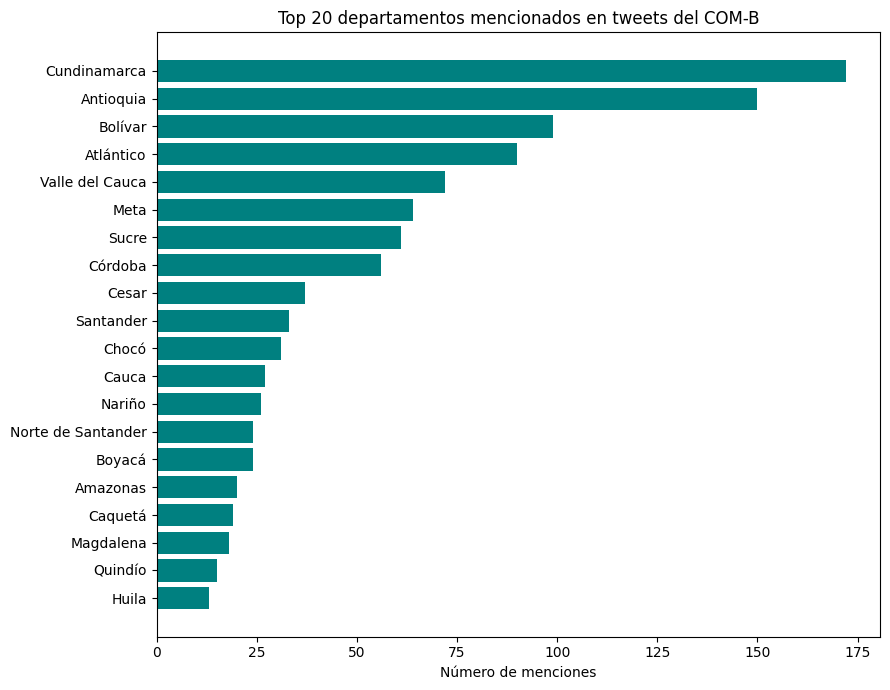

[GUARDADO] fig_top_departamentos_comp.png
      Departamento  Frecuencia
      Cundinamarca         172
         Antioquia         150
           Bolívar          99
         Atlántico          90
   Valle del Cauca          72
              Meta          64
             Sucre          61
           Córdoba          56
             Cesar          37
         Santander          33
             Chocó          31
             Cauca          27
            Nariño          26
            Boyacá          24
Norte de Santander          24
          Amazonas          20
           Caquetá          19
         Magdalena          18
           Quindío          15
             Huila          13


In [6]:
# ============================================================
# CELL 5 — TOP DEPARTAMENTOS
# ============================================================
freq_depto = (
    df_res_depto.groupby('Departamento').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 7))
freq_depto_top = freq_depto.head(20)
freq_depto_top_sorted = freq_depto_top.sort_values('Frecuencia', ascending=True)
ax.barh(freq_depto_top_sorted['Departamento'], freq_depto_top_sorted['Frecuencia'], color='teal')
ax.set_title('Top 20 departamentos mencionados en tweets del COM-B')
ax.set_xlabel('Número de menciones')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_departamentos_comp.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_departamentos_comp.png')
print(freq_depto.head(20).to_string(index=False))


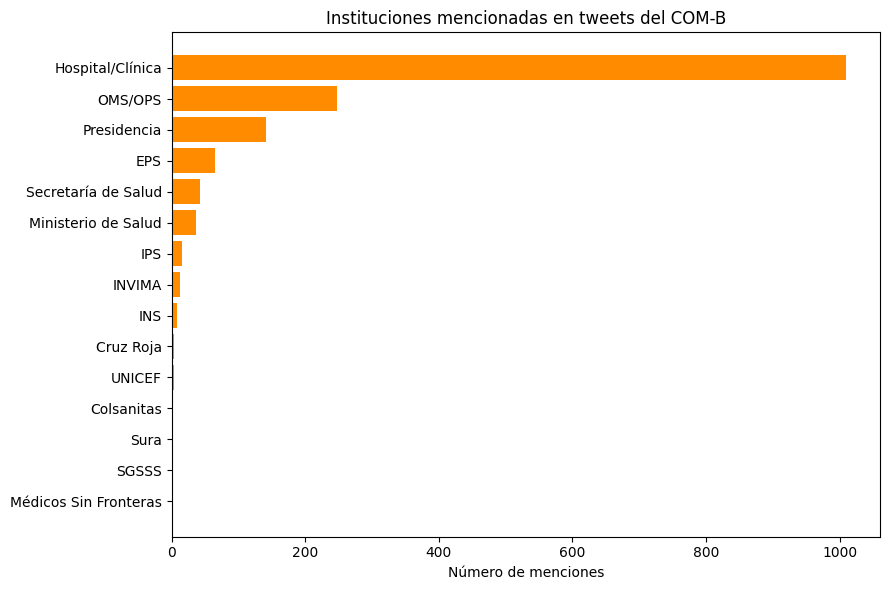

[GUARDADO] fig_top_instituciones_comp.png
          Institucion  Frecuencia
     Hospital/Clínica        1010
              OMS/OPS         248
          Presidencia         141
                  EPS          65
  Secretaría de Salud          43
  Ministerio de Salud          37
                  IPS          16
               INVIMA          12
                  INS           8
            Cruz Roja           4
               UNICEF           3
           Colsanitas           1
Médicos Sin Fronteras           1
                SGSSS           1
                 Sura           1


In [7]:
# ============================================================
# CELL 6 — TOP INSTITUCIONES
# ============================================================
freq_inst = (
    df_res_inst.groupby('Institucion').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))
freq_inst_s = freq_inst.sort_values('Frecuencia', ascending=True)
ax.barh(freq_inst_s['Institucion'], freq_inst_s['Frecuencia'], color='darkorange')
ax.set_title('Instituciones mencionadas en tweets del COM-B')
ax.set_xlabel('Número de menciones')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_instituciones_comp.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_instituciones_comp.png')
print(freq_inst.to_string(index=False))


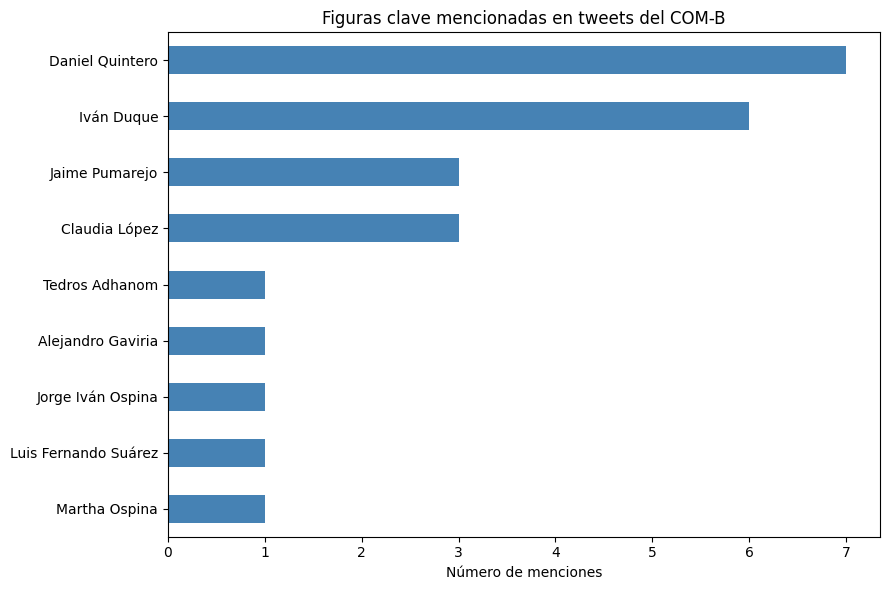

[GUARDADO] fig_top_autores_comportamiento_busqueda.png
          Autor_comp  Frecuencia
     Daniel Quintero           7
          Iván Duque           6
       Claudia López           3
      Jaime Pumarejo           3
   Alejandro Gaviria           1
   Jorge Iván Ospina           1
Luis Fernando Suárez           1
       Martha Ospina           1
      Tedros Adhanom           1


In [8]:
# ============================================================
# CELL 5b — TOP AUTORES / FIGURAS CLAVE
# Equivalente a la búsqueda de autores literarios de Karen
# ============================================================

freq_autores = (
    df_res_autores.groupby('Autor_comp').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))
freq_autores.sort_values('Frecuencia', ascending=True).plot.barh(
    x='Autor_comp', y='Frecuencia', ax=ax, color='steelblue', legend=False
)
ax.set_title('Figuras clave mencionadas en tweets del COM-B')
ax.set_xlabel('Número de menciones')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_autores_comportamiento_busqueda.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_autores_comportamiento_busqueda.png')
print(freq_autores.to_string(index=False))


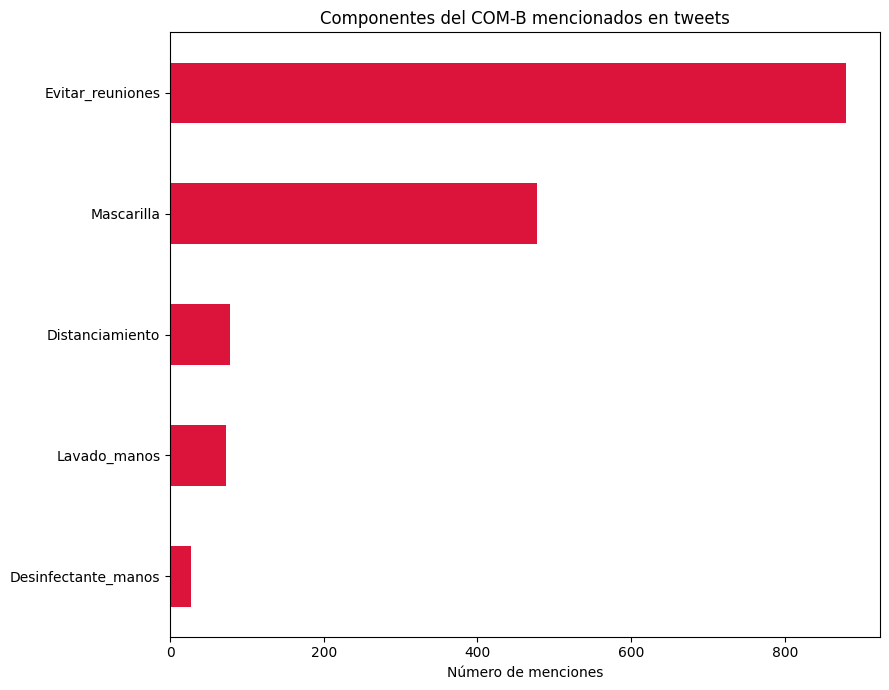

[GUARDADO] fig_top_comportamientos_comp.png
     Comportamiento  Frecuencia
   Evitar_reuniones         880
         Mascarilla         477
    Distanciamiento          78
       Lavado_manos          72
Desinfectante_manos          27


In [9]:
# ============================================================
# CELL 5c — TOP ENFERMEDADES
# ============================================================

freq_comp = (
    df_res_comp.groupby('Comportamiento').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 7))
freq_comp.sort_values('Frecuencia', ascending=True).plot.barh(
    x='Comportamiento', y='Frecuencia', ax=ax, color='crimson', legend=False
)
ax.set_title('Componentes del COM-B mencionados en tweets')
ax.set_xlabel('Número de menciones')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_comportamientos_comp.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_comportamientos_comp.png')
print(freq_comp.to_string(index=False))


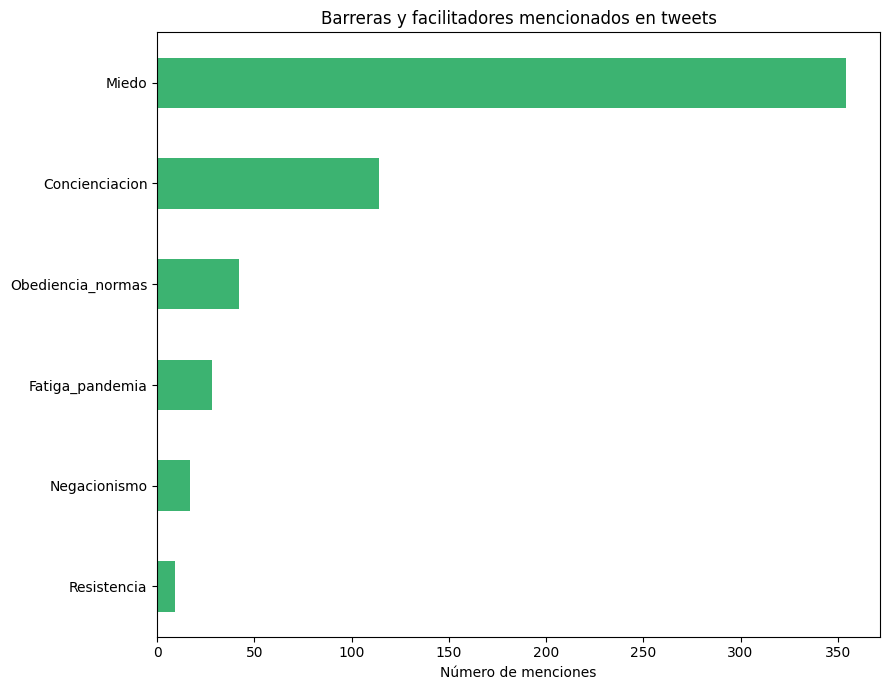

[GUARDADO] fig_top_barreras_comp.png
Barrera_Facilitador  Frecuencia
              Miedo         354
     Concienciacion         114
  Obediencia_normas          42
    Fatiga_pandemia          28
       Negacionismo          17
        Resistencia           9


In [10]:
# ============================================================
# CELL 5d — TOP MEDICAMENTOS
# ============================================================

freq_bar = (
    df_res_bar.groupby('Barrera_Facilitador').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 7))
freq_bar.sort_values('Frecuencia', ascending=True).plot.barh(
    x='Barrera_Facilitador', y='Frecuencia', ax=ax, color='mediumseagreen', legend=False
)
ax.set_title('Barreras y facilitadores mencionados en tweets')
ax.set_xlabel('Número de menciones')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_barreras_comp.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_barreras_comp.png')
print(freq_bar.to_string(index=False))


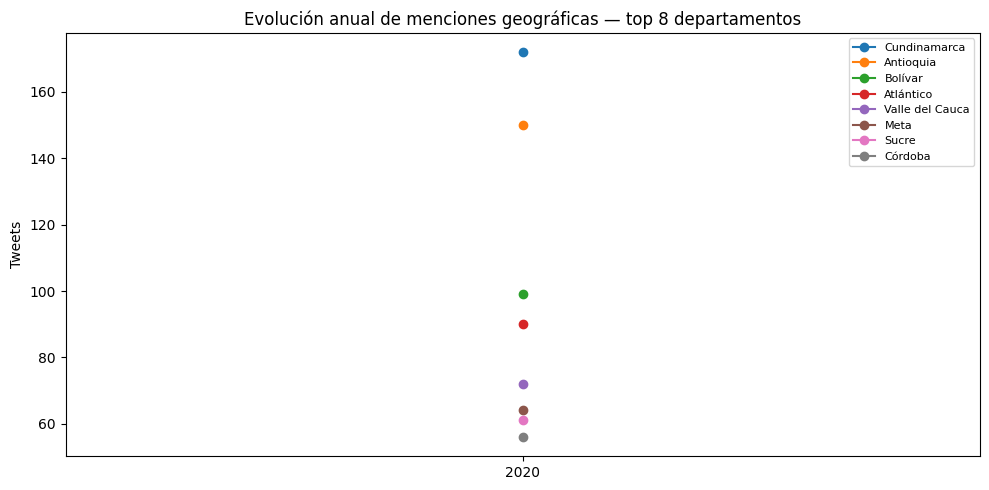

[GUARDADO] fig_evolucion_departamentos_comp.png


In [11]:
# ============================================================
# CELL 7 — EVOLUCIÓN TEMPORAL DE LUGARES E INSTITUCIONES
# ============================================================
df_res_depto['Anio'] = pd.to_datetime(df_res_depto['Fecha']).dt.year

evol_depto = (
    df_res_depto.groupby(['Anio', 'Departamento']).size()
    .reset_index(name='n')
)

# Top 8 departamentos para la visualización
top8_deptos = freq_depto.head(8)['Departamento'].tolist()
evol_depto_top = evol_depto[evol_depto['Departamento'].isin(top8_deptos)]

fig, ax = plt.subplots(figsize=(10, 5))
for depto in top8_deptos:
    sub = evol_depto_top[evol_depto_top['Departamento'] == depto]
    ax.plot(sub['Anio'].astype(str), sub['n'], marker='o', label=depto)

ax.set_title('Evolución anual de menciones geográficas — top 8 departamentos')
ax.set_ylabel('Tweets')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_evolucion_departamentos_comp.png', dpi=300)
plt.show()
print('[GUARDADO] fig_evolucion_departamentos_comp.png')


In [12]:
# ============================================================
# CELL 8 — NER: ANÁLISIS DE ENTIDADES LOC DESDE comb_ner
# (complementa la búsqueda por regex con las entidades ya extraídas)
# ============================================================
comb_ner = pd.read_parquet(DATA_PROCESSED / 'comb_ner.parquet')

# Aplanar entidades LOC
loc_rows = []
for _, row in comb_ner.iterrows():
    for ent in row['entidades']:
        if len(ent) == 2 and ent[0] == 'LOC':
            loc_rows.append({
                'id_doc'   : row['id_doc'],
                'Anio'     : row['Anio'],
                'Entidad'  : str(ent[1]).strip(),
            })

df_loc_ner = pd.DataFrame(loc_rows)

freq_loc = (
    df_loc_ner.groupby('Entidad').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

print(f'Entidades LOC (NER) en subcorpus del COM-B: {len(df_loc_ner):,} menciones')
print(f'Entidades únicas: {freq_loc["Entidad"].nunique():,}')
print()
print('Top 20 lugares (NER):')
print(freq_loc.head(20).to_string(index=False))


Entidades LOC (NER) en subcorpus del COM-B: 6,281 menciones
Entidades únicas: 2,274

Top 20 lugares (NER):
         Entidad  Frecuencia
        Colombia         437
           China         392
          Madrid         181
          México         138
          Bogotá         118
            Cuba         100
Vicente Guerrero          89
            EEUU          81
     San Agustín          81
           Rusia          78
        Medellín          73
    Barranquilla          63
            Cali          53
       Antioquia          50
     Puerto Rico          44
       Cartagena          39
             USA          37
       Andalucía          34
  Estados Unidos          34
        Santiago          33


In [13]:
# ============================================================
# CELL 9 — GUARDAR TODOS LOS RESULTADOS
# ============================================================

# Asegurar tipos string para parquet
def limpiar_para_parquet(df, cols_str):
    for col in cols_str:
        if col in df.columns:
            df[col] = df[col].astype(str)
    return df

df_res_depto   = limpiar_para_parquet(df_res_depto,   ['Departamento', 'Texto_limpio', 'Variante_hallada'])
df_res_inst    = limpiar_para_parquet(df_res_inst,    ['Institucion',  'Texto_limpio', 'Variante_hallada'])
df_res_autores = limpiar_para_parquet(df_res_autores, ['Autor_comp',  'Texto_limpio', 'Variante_hallada'])
df_res_comp     = limpiar_para_parquet(df_res_comp,     ['Comportamiento',   'Texto_limpio', 'Variante_hallada'])
df_res_bar     = limpiar_para_parquet(df_res_bar,     ['Barrera_Facilitador',  'Texto_limpio', 'Variante_hallada'])

df_res_depto.to_parquet(DATA_PROCESSED / 'resultados_departamentos_comb.parquet', index=False)
df_res_inst.to_parquet(DATA_PROCESSED    / 'resultados_instituciones_comb.parquet', index=False)
df_res_autores.to_parquet(DATA_PROCESSED / 'resultados_autores_comb.parquet', index=False)
df_res_comp.to_parquet(DATA_PROCESSED    / 'resultados_comportamientos.parquet', index=False)
df_res_bar.to_parquet(DATA_PROCESSED    / 'resultados_barreras.parquet', index=False)

ruta_excel = DATA_PROCESSED / 'busqueda_terminos_comb.xlsx'
with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    freq_depto.to_excel(writer,   sheet_name='Departamentos',   index=False)
    freq_inst.to_excel(writer,    sheet_name='Instituciones',   index=False)
    freq_autores.to_excel(writer, sheet_name='Autores',         index=False)
    freq_comp.to_excel(writer,     sheet_name='Comportamientos',    index=False)
    freq_bar.to_excel(writer,     sheet_name='Barreras_Facilitadores',    index=False)
    freq_loc.head(100).to_excel(writer, sheet_name='LOC_NER',   index=False)
    df_res_depto.drop(columns=['Texto_limpio'], errors='ignore').to_excel(
        writer, sheet_name='Menciones_departamentos', index=False)
    df_res_inst.drop(columns=['Texto_limpio'], errors='ignore').to_excel(
        writer, sheet_name='Menciones_instituciones', index=False)
    df_res_autores.drop(columns=['Texto_limpio'], errors='ignore').to_excel(
        writer, sheet_name='Menciones_autores', index=False)
    df_res_comp.drop(columns=['Texto_limpio'], errors='ignore').to_excel(
        writer, sheet_name='Menciones_enfermedades', index=False)
    df_res_bar.drop(columns=['Texto_limpio'], errors='ignore').to_excel(
        writer, sheet_name='Menciones_medicamentos', index=False)

print('[GUARDADO] 5 archivos .parquet')
print(f'[GUARDADO] {ruta_excel.name}  ({ruta_excel})')
print()
print('Notebook 10 completado.')
print('Siguiente -> 11_descriptivos_avanzados_comb.ipynb')


[GUARDADO] 5 archivos .parquet
[GUARDADO] busqueda_terminos_comb.xlsx  (C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB\busqueda_terminos_comb.xlsx)

Notebook 10 completado.
Siguiente -> 11_descriptivos_avanzados_comb.ipynb


## Extra · Marcadores lingüísticos del COM-B (búsqueda literal)
Complemento a la clasificación por embeddings: búsqueda **literal** de los
marcadores lingüísticos más distintivos de cada subcomponente (tomados del
documento de palabras clave). Sirve como validación léxica de la
clasificación semántica.


Menciones de marcadores COM-B: 416


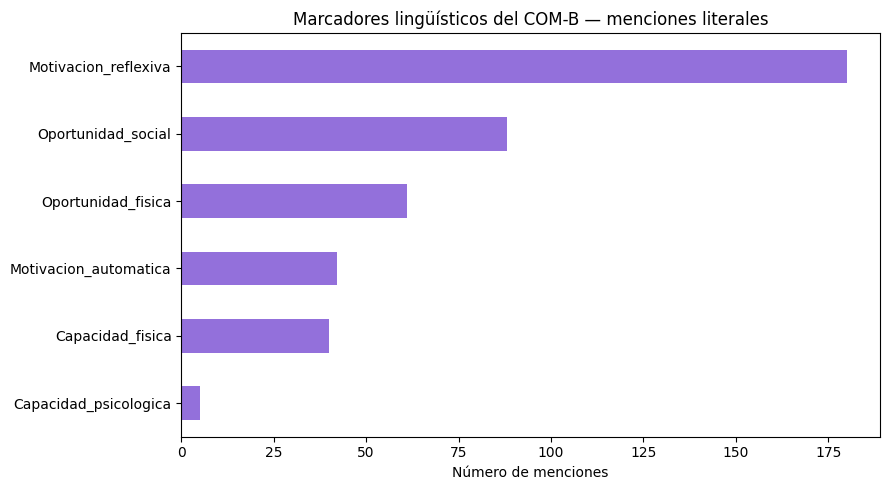

[GUARDADO] fig_marcadores_comb.png
      Componente_COMB  Frecuencia
 Motivacion_reflexiva         180
   Oportunidad_social          88
   Oportunidad_fisica          61
Motivacion_automatica          42
     Capacidad_fisica          40
Capacidad_psicologica           5
[GUARDADO] resultados_marcadores_comb.parquet / frecuencia_marcadores_comb.xlsx


In [14]:
# ============================================================
# CELL EXTRA — MARCADORES LINGÜISTICOS DEL COM-B
# Busqueda literal (normalizada) de frases marcador por subcomponente.
# ============================================================

marcadores_comb = {
    'Motivacion_reflexiva': [
        'quiero vacunarme', 'voy a cuidarme', 'me propongo', 'tengo la intencion',
        'creo que', 'considero que', 'me parece que', 'estoy convencido',
        'vale la pena', 'debo cuidarme', 'es mi responsabilidad', 'es lo correcto',
        'no creo en el virus', 'es una conspiracion', 'nos enganan',
    ],
    'Motivacion_automatica': [
        'me encanta', 'me emociona', 'me alegra', 'que felicidad',
        'me da miedo', 'miedo al contagio', 'angustia', 'me da rabia',
        'no aguanto mas', 'ya no puedo', 'no es justo',
        'por costumbre', 'sin pensarlo', 'ya me acostumbre',
        'necesito salir', 'no aguanto encerrado', 'me urge',
    ],
    'Oportunidad_fisica': [
        'no hay vacunas', 'no hay camas', 'no hay insumos', 'hay dosis',
        'consegui la vacuna', 'escasez', 'no consigo', 'sin acceso', 'agotado',
        'no tengo para', 'el subsidio no alcanza', 'perdi el trabajo',
        'colapso hospitalario', 'falta oxigeno', 'no hay respiradores',
        'no da abasto', 'hacinados', 'sin ventilacion',
    ],
    'Oportunidad_social': [
        'todo el mundo', 'nadie usa tapabocas', 'la gente ya no se cuida',
        'me ayudaron', 'vecinos solidarios', 'ollas comunitarias', 'donaciones',
        'me obligaron', 'me presionan', 'que diran',
        'cadena de whatsapp', 'escuche que', 'me dijeron que',
        'la oms recomienda', 'minsalud dice', 'los medicos advierten',
        'es la costumbre', 'tradicion', 'discriminan', 'estigma',
    ],
    'Capacidad_fisica': [
        'no puedo respirar', 'me deja sin fuerzas', 'dolor muscular', 'fatiga',
        'discapacidad', 'agotamiento', 'soy asintomatico', 'sintomas leves',
        'di positivo', 'estoy en uci', 'me recupere', 'tengo covid',
    ],
    'Capacidad_psicologica': [
        'se como se contagia', 'conozco los sintomas', 'no sabia que',
        'no me quedo claro', 'me confunden', 'dificil de entender',
        'se me olvida el tapabocas', 'no puedo concentrarme',
        'soy capaz de cuidarme', 'no se si aguanto', 'me desborda',
        'me abruman las noticias', 'no se si vacunarme', 'me cuesta decidir',
    ],
}

df_res_marc = buscar_terminos(df_comp, marcadores_comb, 'Componente_COMB')
print(f'Menciones de marcadores COM-B: {len(df_res_marc):,}')

freq_marc = (
    df_res_marc.groupby('Componente_COMB').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
freq_marc.sort_values('Frecuencia', ascending=True).plot.barh(
    x='Componente_COMB', y='Frecuencia', ax=ax, color='mediumpurple', legend=False
)
ax.set_title('Marcadores lingüísticos del COM-B — menciones literales')
ax.set_xlabel('Número de menciones')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_marcadores_comb.png', dpi=300)
plt.show()
print('[GUARDADO] fig_marcadores_comb.png')
print(freq_marc.to_string(index=False))

# Guardar
df_res_marc_save = df_res_marc.copy()
for col in ['Componente_COMB', 'Texto_limpio', 'Variante_hallada']:
    if col in df_res_marc_save.columns:
        df_res_marc_save[col] = df_res_marc_save[col].astype(str)
df_res_marc_save.to_parquet(DATA_PROCESSED / 'resultados_marcadores_comb.parquet', index=False)
freq_marc.to_excel(DATA_PROCESSED / 'frecuencia_marcadores_comb.xlsx',
                   index=False, engine='openpyxl')
print('[GUARDADO] resultados_marcadores_comb.parquet / frecuencia_marcadores_comb.xlsx')
